(chap_m1s6)=
# Image-Based Models

:::{admonition} Chapter Overview
:class: tip

By the end of this module, you should be able to:

* Describe how digital images are represented as pixel arrays or tensors, including height, width, channels, and batch dimensions.
* Differentiate image classification, object detection, and image segmentation, and connect each task to a healthcare use case.
* Explain at a high level how convolutional neural networks (CNNs) learn spatial features and how transfer learning can reduce the amount of task-specific training data required.
* Build and evaluate a basic image classifier using a small, public biomedical image dataset.
* Critically assess image-based models for data leakage, class imbalance, shortcut learning, domain shift, interpretability limitations, and lack of clinical generalizability.
:::

:::{admonition} Educational use only
:class: warning

The model developed in this module is an educational example. It is **not a diagnostic system** and must not be used to make clinical decisions. PneumoniaMNIST contains low-resolution pediatric chest X-rays and does not represent the full diversity or complexity of clinical imaging.
:::


## Before You Begin

This module assumes that you are comfortable with:

* Basic Python and Jupyter notebooks
* NumPy arrays and Matplotlib
* Supervised learning, labels, and train/validation/test splits
* Basic classification metrics
* Neural-network concepts such as layers, activation functions, loss functions, and optimization


### Practical example

The guided coding example uses **PneumoniaMNIST**, a binary image-classification dataset from the [MedMNIST collection](https://medmnist.com/). The dataset contains 5,856 standardized pediatric chest X-ray images divided into predefined training, validation, and test splits.

The workflow will:

1. Inspect the images, labels, dimensions, pixel values, and class balance.
2. Apply normalization and limited training-only augmentation.
3. Train a small CNN using PyTorch.
4. Evaluate the model using AUROC, sensitivity, specificity, precision, F1 score, and a confusion matrix.
5. Review false positives, false negatives, and a Grad-CAM heatmap.
6. End with a clinical-translation check.


## Setup

The following cell installs the packages used in the practical example. In Google Colab, run it once at the beginning of the session. In a local environment, you may prefer to install these packages using your usual environment manager.

:::{admonition} Reproducibility note
:class: info

:::


#### Install the Required Packages

In [34]:
# Run once if the required packages are not already installed.
%pip install -q medmnist captum scikit-learn matplotlib pandas


Note: you may need to restart the kernel to use updated packages.


#### Import Libraries and Configure the Environment

In [35]:
# Imports used throughout the module.

import random
import sys
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

import medmnist
from medmnist import INFO

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    roc_auc_score,
)

# Set parameters for figures
plt.rcParams.update({
    "font.size": 12,
    "figure.titlesize": 20,
    "figure.titleweight": "bold",
    "axes.titlesize": 16,
    # "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})


SEED = 21
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


#### Record Package Versions

In [36]:
# Record package versions to support reproducibility.
packages = [
    "python", "numpy", "pandas", "matplotlib",
    "torch", "torchvision", "medmnist",
    "scikit-learn", "captum"
]

for package in packages:
    if package == "python":
        package_version = sys.version.split()[0]
    else:
        try:
            package_version = version(package)
        except PackageNotFoundError:
            package_version = "not installed"
    print(f"{package:14s}: {package_version}")


python        : 3.14.6
numpy         : 2.5.1
pandas        : 3.0.5
matplotlib    : 3.11.1
torch         : 2.13.0+cu126
torchvision   : 0.28.0+cu126
medmnist      : 3.0.2
scikit-learn  : 1.9.0
captum        : 0.9.0


## 1. What Makes Image Data Different?

Image data are widely used in healthcare and biomedical research. Examples include radiological imaging, histopathology, clinical photography, endoscopy, and dental imaging. Although these images come from different clinical settings and imaging technologies, machine-learning models ultimately process them as numerical arrays.

```{figure} medmnist_examples_224.png
:align: center
:width: 95%
:name: fig-medmnist-examples

Examples of healthcare and biomedical image data from MedMNIST. Sources: [@yang2023medmnist; @10.1371/journal.pmed.1002730; @Wang_2017; @tschandl_ham10000_2018; @kermany2018identifying; @kermany2018largedataset; @LIU2022100512; @aldhabyani2020breastultrasound; @ACEVEDO2020105474; @ljosa2012annotated; @bilic2023liver ].
```

Images consist of **spatially organized pixels**. Neighbouring pixels are often related, and the location of a visual pattern within an image may be important.

A grayscale image can be represented as a two-dimensional array:

```{math}
:label: grayscale-image-shape

\text{image shape} = H \times W
```

where {math}`H` is the image height and {math}`W` is the image width.

Deep-learning frameworks usually add a **channel dimension**:

```{math}
:label: image-channel-shape

C \times H \times W
```

For a grayscale image, {math}`C = 1`. For a standard red-green-blue, or RGB, image, {math}`C = 3`.

When multiple images are processed together, a **batch dimension** is added:

```{math}
:label: image-batch-shape

N \times C \times H \times W
```

where {math}`N` is the number of images in the batch.

:::{admonition} Framework convention
:class: note

PyTorch usually stores image batches in the order {math}`N \times C \times H \times W`.

Other frameworks may use {math}`N \times H \times W \times C`. Always inspect the tensor shape rather than assuming the dimension order.


#### Visualize an Image and Its Pixel Values

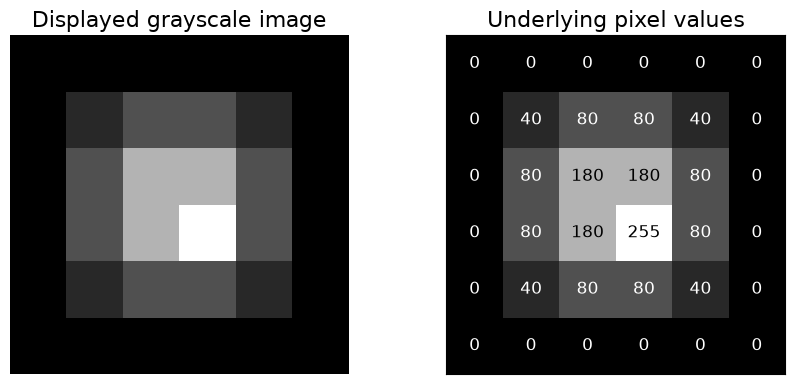

In [37]:
#| label: pixel-values-output
# Create a small synthetic grayscale image to connect pixel values,
# array dimensions, and displayed intensity.


example_image = np.array(
    [
        [0,   0,   0,   0,   0,   0],
        [0,  40,  80,  80,  40,   0],
        [0,  80, 180, 180,  80,   0],
        [0,  80, 180, 255,  80,   0],
        [0,  40,  80,  80,  40,   0],
        [0,   0,   0,   0,   0,   0],
    ],
    dtype=np.uint8,
)

threshold = 150

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(example_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Displayed grayscale image")
axes[0].axis("off")

axes[1].imshow(example_image, cmap="gray", vmin=0, vmax=255)

for row in range(example_image.shape[0]):
    for col in range(example_image.shape[1]):
        value = example_image[row, col]

        axes[1].text(
            col,
            row,
            str(value),
            ha="center",
            va="center",
            color="white" if value < threshold else "black",
        )

axes[1].set_title("Underlying pixel values")
axes[1].set_xticks([])
axes[1].set_yticks([])

fig.tight_layout()


:::{figure} #pixel-values-output
:label: fig-pixel-values
:align: center
:width: 85%

A grayscale image and its underlying pixel values. Although the image is displayed visually, it is stored and processed as a numerical array.

:::

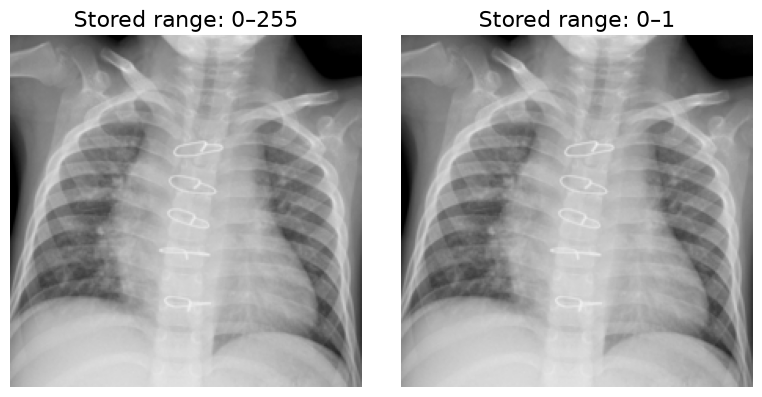

In [38]:
#| label: pixel-range-output
# Load a higher-resolution PneumoniaMNIST image for visualization only
pneumonia_224 = medmnist.PneumoniaMNIST(
    split="train",
    download=True,
    size=224,
)

image, label = pneumonia_224[0]

# Convert PIL image to NumPy array
image_255 = np.asarray(image)

# Scale from 0–255 to 0–1
image_01 = image_255.astype(np.float32) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image_255, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Stored range: 0–255")

axes[1].imshow(image_01, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Stored range: 0–1")

for ax in axes:
    ax.axis("off")

fig.tight_layout()
# fig

:::{figure} #pixel-range-output
:label: fig-pixel-range
:align: center
:width: 80%

The same chest X-ray represented using pixel values from 0–255 (left) and 0–1 (right).

:::

Images can be represented using different numerical ranges. For example, an 8-bit image commonly uses integer values from **0 to 255**, while the same image can be converted to floating-point values and scaled to **0 to 1**.

Although the numerical values are different, the two images in {numref}`fig-pixel-range` look the same because each range is mapped appropriately to grayscale when displayed.

Medical images may use other intensity ranges depending on the imaging modality and acquisition process. Knowing the underlying pixel-value range is important when normalizing, thresholding, or comparing images.

#### Convert an Image Array into a PyTorch Tensor

In [39]:
# Convert the 2D NumPy array into the channel-first format used by PyTorch.
image_tensor = torch.tensor(example_image, dtype=torch.float32).unsqueeze(0)

# Add a batch dimension.
image_batch = image_tensor.unsqueeze(0)

print("NumPy image shape:  ", example_image.shape, "      -> H x W")
print("PyTorch image shape:", tuple(image_tensor.shape), "   -> C x H x W")
print("PyTorch batch shape:", tuple(image_batch.shape), "-> N x C x H x W")


NumPy image shape:   (6, 6)       -> H x W
PyTorch image shape: (1, 6, 6)    -> C x H x W
PyTorch batch shape: (1, 1, 6, 6) -> N x C x H x W


:::{admonition} Check your understanding
:class: question

A PyTorch batch has shape `(32, 1, 28, 28)`.

1. How many images are in the batch?
2. Are the images grayscale or RGB?
3. What are the image height and width?

```{dropdown} Answer
There are 32 grayscale images. Each image is 28 pixels high and 28 pixels wide.
```
:::


## 2. Common Image-Based Prediction Tasks

Three common image-based tasks are classification, detection, and segmentation.

| Task | Input | Model output | Healthcare example |
|--|---|---|---|
| **Classification** | One image or image volume | One or more labels | Predict pneumonia versus normal from a chest X-ray |
| **Object detection** | One image | Bounding boxes and class labels | Locate a brain tumour in an MRI or CT scan |
| **Segmentation** | One image or image volume | Pixel- or voxel-level mask | Segment the spleen in a CT volume |

Deep learning has been applied to classification, detection, segmentation, and other tasks across a range of medical imaging modalities [@litjens2017survey].

Different tasks generally require different model architectures and outputs. For example, **YOLO** models can be used for object detection by predicting the location and class of objects within an image, while architectures such as **U-Net** can be used for segmentation by assigning a class label to individual pixels or voxels.

:::{admonition} Explore detection and segmentation
:class: tip

This module focuses on **binary image classification**, but if you are interested in the other image-based tasks, you can explore these healthcare-focused examples:

- **Object detection:** [Brain tumour detection with Ultralytics YOLO](https://colab.research.google.com/github/ultralytics/notebooks/blob/main/notebooks/how-to-train-ultralytics-yolo-on-brain-tumor-detection-dataset.ipynb), which demonstrates training an object-detection model on annotated brain MRI and CT images.
- **Segmentation:** [3D spleen segmentation with MONAI](https://github.com/Project-MONAI/tutorials/blob/main/3d_segmentation/spleen_segmentation_3d.ipynb), which demonstrates 3D U-Net segmentation of the spleen from CT volumes.

:::

#### Compare Classification, Detection, and Segmentation

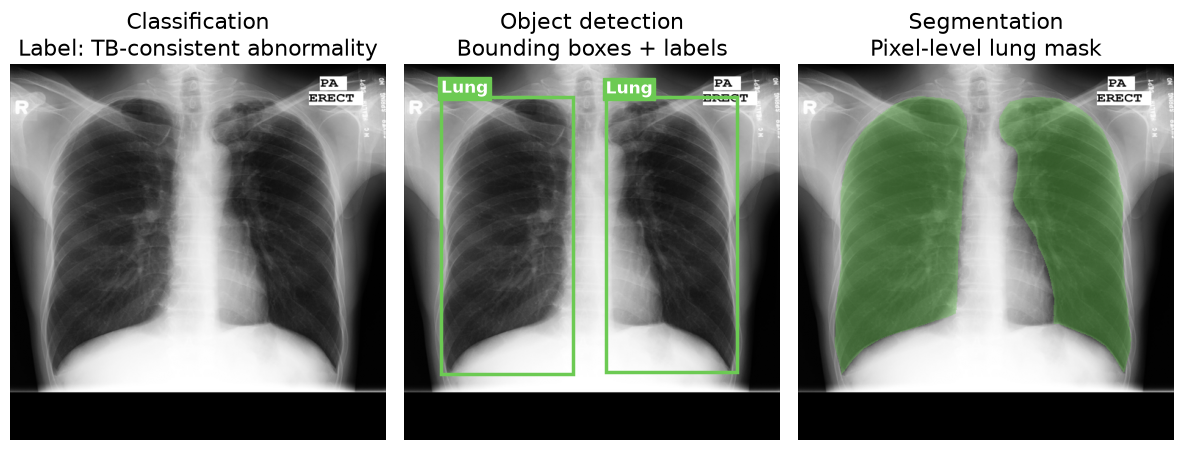

In [40]:
#| label: image-tasks-output
# Compare classification, object detection, and segmentation using
# a real chest X-ray from the Montgomery County CXR dataset.



# "_1" indicates an abnormal image with TB-consistent manifestations.
filename = "MCUCXR_0104_1.png"

data_dir = Path("data/montgomery_example")
data_dir.mkdir(parents=True, exist_ok=True)

image_path = data_dir / filename
left_mask_path = data_dir / f"left_{filename}"
right_mask_path = data_dir / f"right_{filename}"

# ------------------------------------------------------------------
# Load and resize the image and masks
# ------------------------------------------------------------------

display_size = (512, 512)
pastel_red = "#6CCA53"

cxr = Image.open(image_path).resize(
    display_size,
    Image.Resampling.LANCZOS,
)

left_mask = Image.open(left_mask_path).convert("L").resize(
    display_size,
    Image.Resampling.NEAREST,
)

right_mask = Image.open(right_mask_path).convert("L").resize(
    display_size,
    Image.Resampling.NEAREST,
)

cxr = np.asarray(cxr, dtype=np.float32)
left_mask = np.asarray(left_mask) > 0
right_mask = np.asarray(right_mask) > 0

lung_mask = left_mask | right_mask


# Normalize the chest X-ray for display.
low, high = np.percentile(cxr, [1, 99])

cxr = np.clip(
    (cxr - low) / (high - low + 1e-8),
    0,
    1,
)


# ------------------------------------------------------------------
# Derive detection-style bounding boxes from the manual masks
# ------------------------------------------------------------------

def bounding_box(mask):
    rows, cols = np.where(mask)

    x_min = cols.min()
    x_max = cols.max()
    y_min = rows.min()
    y_max = rows.max()

    return x_min, y_min, x_max, y_max


left_box = bounding_box(left_mask)
right_box = bounding_box(right_mask)


# ------------------------------------------------------------------
# Visualize the three prediction tasks
# ------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))


# Classification ---------------------------------------------------

axes[0].imshow(cxr, cmap="gray", vmin=0, vmax=1)

axes[0].set_title(
    "Classification\n"
    "Label: TB-consistent abnormality"
)

axes[0].axis("off")


# Object detection -------------------------------------------------

axes[1].imshow(cxr, cmap="gray", vmin=0, vmax=1)

for box, label in [
    (left_box, "Lung"),
    (right_box, "Lung"),
]:
    x_min, y_min, x_max, y_max = box

    rectangle = plt.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        fill=False,
        linewidth=2.5,
        edgecolor=pastel_red,
    )

    axes[1].add_patch(rectangle)

    axes[1].text(
        x_min,
        y_min,
        label,
        color="white",
        fontweight="bold",
        ha="left",
        va="bottom",
        bbox={
            "facecolor": pastel_red,
            "edgecolor": pastel_red,
            "pad": 2,
        },
    )

axes[1].set_title(
    "Object detection\n"
    "Bounding boxes + labels"
)

axes[1].axis("off")


# Segmentation -----------------------------------------------------

axes[2].imshow(cxr, cmap="gray", vmin=0, vmax=1)

segmentation_overlay = np.ma.masked_where(
    ~lung_mask,
    lung_mask,
)

axes[2].imshow(
    segmentation_overlay,
    cmap=ListedColormap([pastel_red]),
    alpha=0.4,
)

axes[2].set_title(
    "Segmentation\n"
    "Pixel-level lung mask"
)

axes[2].axis("off")


fig.tight_layout()


:::{figure} #image-tasks-output
:label: fig-image-tasks
:align: center
:width: 90%

A simplified conceptual comparison of image classification, object detection, and image segmentation. The bright circular region represents a synthetic abnormality rather than a realistic clinical finding.

:::

:::{admonition} Important distinction
:class: info

A classification model may predict that an abnormality is present, but it does not necessarily identify **where** the abnormality is. A heatmap generated after classification is not equivalent to a detection box or a validated segmentation mask.
:::


## 3. Preparing Images for a Model

Common preprocessing steps include:

* **Resizing:** changing the spatial dimensions of an image
* **Cropping:** selecting part of an image
* **Normalization:** transforming pixel values to a consistent scale
* **Registration:** spatially aligning images to a common coordinate system
* **Augmentation:** introducing realistic training-time variation
* **Batching:** grouping images for efficient computation
* **Data loading:** reading and transforming data during training

Preprocessing is not neutral. A transformation may remove clinically important detail, create unrealistic anatomy, or alter laterality. The appropriate choices depend on the modality, anatomy, acquisition process, and intended task.

:::{admonition} Preventing data leakage
:class: warning

Learn preprocessing parameters from the **training set only**. Keep patient-related images in the same split. Augmentation should be applied only to training data, not validation or test data.
:::


### 3.1 Load PneumoniaMNIST

[PneumoniaMNIST](https://medmnist.com/) is one of the standardized biomedical image-classification datasets included in MedMNIST v2 [@yang2023medmnist]. It was constructed from the pediatric chest X-ray dataset reported by Kermany et al. [@kermany2018identifying].

PneumoniaMNIST includes predefined training, validation, and test splits. The version used in this module contains grayscale images standardized to a resolution of {math}`28 \times 28` pixels.

This low resolution makes the dataset computationally accessible for teaching and benchmarking, but it also removes much of the detail available in the original clinical chest X-rays.

#### Review the PneumoniaMNIST Dataset Information

In [41]:
DATA_FLAG = "pneumoniamnist"
DOWNLOAD = True

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

print("Task:           ", info["task"])
print("Number channels:", info["n_channels"])
print("Labels:         ", info["label"])
print(
    textwrap.fill(
        info["description"],
        width=80,
        initial_indent="Description: ",
        subsequent_indent="             ",
    )
)


Task:            binary-class
Number channels: 1
Labels:          {'0': 'normal', '1': 'pneumonia'}
Description: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric
             chest X-Ray images. The task is binary-class classification of
             pneumonia against normal. We split the source training set with a
             ratio of 9:1 into training and validation set and use its source
             validation set as the test set. The source images are gray-scale,
             and their sizes are (384−2,916)×(127−2,713). We center-crop the
             images and resize them into 1×28×28.


#### Load the Training, Validation, and Test Sets

In [42]:
# Load raw datasets so that we can inspect the original arrays.
raw_train_dataset = DataClass(split="train", download=DOWNLOAD)
raw_val_dataset = DataClass(split="val", download=DOWNLOAD)
raw_test_dataset = DataClass(split="test", download=DOWNLOAD)

split_names = ["Training", "Validation", "Test"]
split_sizes = [
    len(raw_train_dataset),
    len(raw_val_dataset),
    len(raw_test_dataset),
]

total = sum(split_sizes)

split_summary = pd.DataFrame({
    "Split": split_names,
    "Number of images": split_sizes,
    "Percentage": [size / total for size in split_sizes],
})

split_summary.style.format({
    "Number of images": "{:,}",
    "Percentage": "{:.1%}",
})

,Split,Number of images,Percentage
0,Training,"4,708",80.4%
1,Validation,524,8.9%
2,Test,624,10.7%


### 3.2 Inspect image dimensions and pixel values

Before training, inspect the dataset rather than assuming that the input has the expected format.


#### Inspect Image Dimensions and Pixel Values

In [43]:
sample_image, sample_label = raw_train_dataset[0]
sample_array = np.asarray(sample_image)

print("Image type:       ", type(sample_image))
print("Image array shape:", sample_array.shape)
print("Image data type:  ", sample_array.dtype)
print("Minimum value:    ", sample_array.min())
print("Maximum value:    ", sample_array.max())
print("Raw label:        ", sample_label)


Image type:        <class 'PIL.Image.Image'>
Image array shape: (28, 28)
Image data type:   uint8
Minimum value:     0
Maximum value:     225
Raw label:         [1]


#### Visualize Examples from Each Class

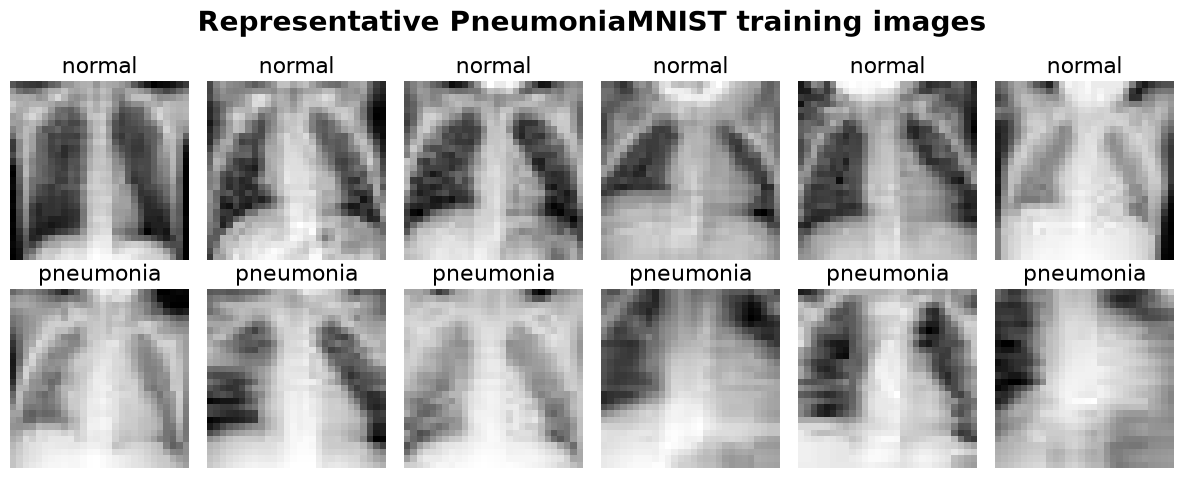

In [44]:
#| label: pneumoniamnist-examples-output
# Display representative images from each class.

dataset = DataClass(
    split="train",
    download=True,
    size=224,
)

label_map = {int(key): value for key, value in info["label"].items()}
train_labels_raw = raw_train_dataset.labels.squeeze().astype(int)

fig, axes = plt.subplots(2, 6, figsize=(12, 5))

for class_id, axis_row in zip(sorted(label_map), axes):
    class_indices = np.where(train_labels_raw == class_id)[0][:6]
    for ax, idx in zip(axis_row, class_indices):
        image, label = raw_train_dataset[int(idx)]
        ax.imshow(image, cmap="gray")
        ax.set_title(label_map[int(np.asarray(label).squeeze())])
        ax.axis("off")

fig.suptitle("Representative PneumoniaMNIST training images")
fig.tight_layout()
plt.show()

:::{figure} #pneumoniamnist-examples-output
:label: fig-pneumoniamnist-examples
:align: center
:width: 95%

Representative low-resolution images from the PneumoniaMNIST training split, organized according to their class labels. Compare these {math}`28 \times 28` images with the higher-resolution {math}`224 \times 224` MedMNIST examples shown in {numref}`fig-medmnist-examples`.

:::

At a resolution of {math}`28 \times 28` pixels, these images contain substantially less detail than the original clinical chest X-rays. Therefore, strong performance on this benchmark should not be interpreted as evidence that the model is ready for clinical use.

### 3.3 Examine class balance

Class imbalance can make accuracy misleading. For example, a model can appear accurate by frequently predicting the more common class.


#### Summarize the Training-Set Class Distribution

In [45]:
class_counts = (
    pd.Series(train_labels_raw)
    .value_counts()
    .sort_index()
    .rename(index=label_map)
    .rename("Count")
    .to_frame()
)

class_counts["Percentage"] = (
    class_counts["Count"] / class_counts["Count"].sum()
)

display(
    class_counts.style
    .format({
        "Count": "{:,}",
        "Percentage": "{:.1%}",
    })
    .set_properties(**{
        "text-align": "center",
        "padding": "8px",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold"),
                ("padding", "8px"),
            ],
        }
    ])
)

,Count,Percentage
normal,"1,214",25.8%
pneumonia,"3,494",74.2%


#### Visualize the Training-Set Class Balance

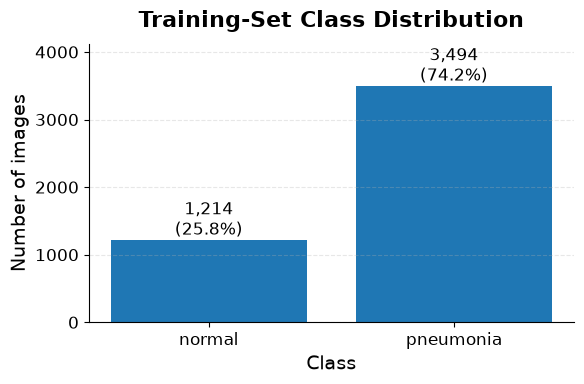

In [46]:
#| label: class-balance-output

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    class_counts.index,
    class_counts["Count"],
)

# Add count and percentage above each bar
for bar, (_, row) in zip(bars, class_counts.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(row["Count"]):,}\n({row["Percentage"]:.1%})',
        ha="center",
        va="bottom",
    )

ax.set_title(
    "Training-Set Class Distribution",
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Class")
ax.set_ylabel("Number of images")

ax.tick_params(axis="x", rotation=0)

# Give labels above bars some breathing room
ax.set_ylim(
    0,
    class_counts["Count"].max() * 1.18,
)

# Subtle horizontal reference lines
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

:::{figure} #class-balance-output
:label: fig-class-balance
:align: center
:width: 60%

Distribution of normal and pneumonia images in the PneumoniaMNIST training split.

:::

:::{admonition} Check your understanding
:class: tip

Would you consider this dataset to be class imbalanced? What problems could arise if one class were much more common than the other?

:::

The training set contains more pneumonia images than normal images, so the classes are not perfectly balanced. However, class imbalance exists on a spectrum rather than as a strict yes-or-no property. When one class substantially outnumbers another, accuracy alone can become misleading because a model may perform well by favouring the majority class.

### 3.4 Define training and evaluation transformations

The training transformation below uses a small random rotation as a limited example of augmentation. It intentionally avoids horizontal flipping because laterality can be clinically meaningful in chest imaging.

Even a small rotation is not automatically appropriate for every medical-imaging task. Augmentations should reflect plausible acquisition or patient-position variation.


#### Define Image Transformations and Normalization

In [47]:
# Estimate normalization values using the training split only.
train_pixels = raw_train_dataset.imgs.astype(np.float32) / 255.0
train_mean = float(train_pixels.mean())
train_std = float(train_pixels.std())

print(f"Training mean: {train_mean:.4f}")
print(f"Training standard deviation: {train_std:.4f}")

train_transform = transforms.Compose(
    [
        transforms.RandomRotation(degrees=5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)

evaluation_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[train_mean], std=[train_std]),
    ]
)

train_dataset = DataClass(split="train", transform=train_transform, download=DOWNLOAD)
val_dataset = DataClass(split="val", transform=evaluation_transform, download=DOWNLOAD)
test_dataset = DataClass(split="test", transform=evaluation_transform, download=DOWNLOAD)

transformed_image, transformed_label = train_dataset[0]
print("Transformed image shape:", tuple(transformed_image.shape))
print("Transformed image dtype:", transformed_image.dtype)
print("Transformed label:      ", transformed_label)


Training mean: 0.5719
Training standard deviation: 0.1684
Transformed image shape: (1, 28, 28)
Transformed image dtype: torch.float32
Transformed label:       [1]


:::{admonition} Reflection
:class: question

What could go wrong if random augmentation were also applied to the validation and test sets?

```{dropdown} Suggested response
Evaluation would become variable and would no longer measure performance on a fixed held-out dataset. Some transformations could also make the evaluation examples unrealistic or change clinically meaningful information.
```
:::


## 4. How Convolutional Neural Networks Work

Convolutional neural networks (CNNs) learn spatial patterns by applying small filters, or **kernels**, across an image. As a kernel moves across the image, it combines values from a local region of the input to produce one value in an output feature map.

The animation below illustrates this process for a two-dimensional convolution with no padding and a stride of one.

```{figure} no_padding_no_strides.gif
:align: center
:width: 55%
:name: fig-convolution-animation

A two-dimensional convolution with no padding and a stride of one. The blue grid represents the input and the green grid represents the output. Reproduced from Dumoulin and Visin [@dumoulin2016guide], available under the MIT License.

Early convolutional neural networks demonstrated how local connectivity and shared weights could support image recognition [@lecun1998gradient]. Later work showed that deeper CNNs trained on large image datasets could achieve major improvements in image-classification performance [@krizhevsky2012imagenet]. This provides three important properties:

1. **Local connectivity:** Each feature is computed from a local neighbourhood of pixels.
2. **Weight sharing:** The same filter is applied across multiple spatial locations.
3. **Preservation of spatial structure:** The resulting feature map retains information about where a pattern was detected.

A simplified two-dimensional convolution-like operation can be written as:

```{math}
:label: two-dimensional-convolution

Z_{i,j}
=
\sum_m \sum_n
X_{i+m,j+n}K_{m,n} + b
```

where {math}`X` is the input image, {math}`K` is the kernel or filter, {math}`b` is the bias term, and {math}`Z` is the resulting feature map.

:::{admonition} Convolution or cross-correlation?
:class: note

Strictly speaking, most deep-learning libraries perform **cross-correlation** when they refer to convolution because the kernel is applied without being flipped. This distinction does not change the main learning concept in this module because the kernel values are learned during training.




#### Apply Example Kernels to an Image

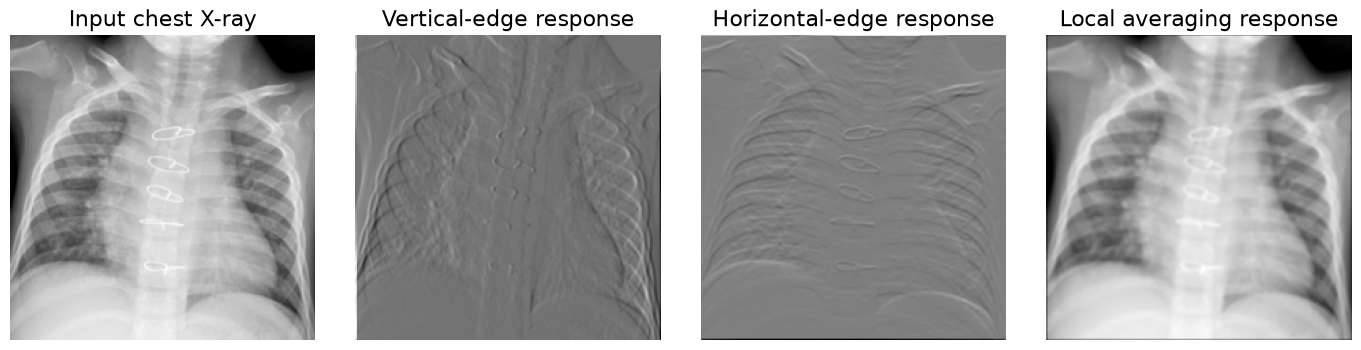

In [48]:
#| label: fixed-kernels-output
# Apply fixed kernels to a PneumoniaMNIST image to illustrate how
# different local filters produce different feature maps.
# In a CNN, these kernel values are learned during training.

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Select one PneumoniaMNIST image
# Load a higher-resolution PneumoniaMNIST image for visualization only
pneumonia_224 = medmnist.PneumoniaMNIST(
    split="train",
    download=True,
    size=224,
)

image, label = pneumonia_224[0]

# Convert to a single-channel float tensor if needed
image = np.array(image)


if image.ndim == 3:
    image = image[0, ...]


image_tensor = torch.tensor(
    image, dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

# Normalize pixel values for visualization
image_tensor = (
    image_tensor - image_tensor.min()
) / (
    image_tensor.max() - image_tensor.min() + 1e-8
)

# Fixed example kernels
vertical_edge_kernel = torch.tensor(
    [[
        [-1.0, 0.0, 1.0],
        [-2.0, 0.0, 2.0],
        [-1.0, 0.0, 1.0],
    ]]
).unsqueeze(0)

horizontal_edge_kernel = torch.tensor(
    [[
        [-1.0, -2.0, -1.0],
        [ 0.0,  0.0,  0.0],
        [ 1.0,  2.0,  1.0],
    ]]
).unsqueeze(0)

blur_kernel = (
    torch.ones((1, 1, 3, 3), dtype=torch.float32) / 9.0
)

# Apply convolution
vertical_features = F.conv2d(
    image_tensor, vertical_edge_kernel, padding=1
)

horizontal_features = F.conv2d(
    image_tensor, horizontal_edge_kernel, padding=1
)

blurred_features = F.conv2d(
    image_tensor, blur_kernel, padding=1
)


# Visualize
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(image_tensor.squeeze(), cmap="gray")
axes[0].set_title("Input chest X-ray")

axes[1].imshow(vertical_features.squeeze(), cmap="gray")
axes[1].set_title("Vertical-edge response")

axes[2].imshow(horizontal_features.squeeze(), cmap="gray")
axes[2].set_title("Horizontal-edge response")

axes[3].imshow(blurred_features.squeeze(), cmap="gray")
axes[3].set_title("Local averaging response")

for ax in axes:
    ax.axis("off")

fig.tight_layout()

:::{figure} #fixed-kernels-output
:label: fig-fixed-kernels
:align: center
:width: 95%

Example responses produced by applying fixed kernels to a 224 × 224 PneumoniaMNIST chest X-ray. The higher-resolution image is used here to make the effects of the filters easier to visualize; the classification exercise in this module uses the 28 × 28 version of PneumoniaMNIST.

:::

After convolution, CNNs commonly use:

* A **nonlinear activation function**, such as ReLU, which allows the network to represent nonlinear relationships.
* **Pooling** or strided convolution to reduce the spatial dimensions of the feature maps.
* Multiple layers that learn progressively more complex representations.
* A final prediction layer that converts the learned features into logits or probabilities.

The spatial output size of a convolutional layer can be calculated as:

```{math}
:label: convolution-output-size

\text{output size}
=
\left\lfloor
\frac{\text{input size} + 2P - K}{S}
\right\rfloor + 1
```

where {math}`P` is the padding size, {math}`K` is the kernel size, and {math}`S` is the stride.


#### Calculate the Convolutional Output Size

In [49]:
def convolution_output_size(input_size, kernel_size, stride=1, padding=0):
    """Calculate one spatial output dimension for a convolutional layer."""
    return ((input_size + 2 * padding - kernel_size) // stride) + 1

print(
    "28x28 input, 3x3 kernel, stride 1, padding 1 ->",
    convolution_output_size(28, 3, stride=1, padding=1),
)

print(
    "28x28 input, 3x3 kernel, stride 2, padding 1 ->",
    convolution_output_size(28, 3, stride=2, padding=1),
)


28x28 input, 3x3 kernel, stride 1, padding 1 -> 28
28x28 input, 3x3 kernel, stride 2, padding 1 -> 14


:::{admonition} Open visualization resources
:class: seealso

* [CNN Explainer](https://poloclub.github.io/cnn-explainer/) provides an interactive visualization of convolution, activation, pooling, and learned feature maps.
* [Convolution Arithmetic](https://github.com/vdumoulin/conv_arithmetic) provides openly licensed animations of padding, stride, dilation, and transposed convolution.
* [Dive into Deep Learning: Convolutional Neural Networks](https://d2l.ai/chapter_convolutional-neural-networks/index.html) provides equations, explanations, and executable examples.
:::


## 5. Image-Based Model Families

This module uses a small convolutional neural network (CNN) because its components can be inspected directly. However, modern image-based systems span several major model families and pretraining paradigms.

| Model family | Core idea | Popular architectures or models |
|---|---|---|
| **Convolutional neural networks (CNNs)** | Learn increasingly complex spatial features by applying convolutional filters across an image | AlexNet, VGGNet, GoogLeNet/Inception, ResNet, EfficientNet |
| **Vision transformers (ViTs)** | Divide an image into patches and use self-attention to model relationships between image regions | ViT, DeiT, Swin Transformer |
| **Vision foundation models** | Pretrain large models on broad image datasets so that learned visual representations can be reused or adapted across downstream tasks | DINOv2, Segment Anything Model (SAM), CLIP* |

\*CLIP jointly learns from images and text and is therefore a multimodal vision-language model rather than a purely image-only model.

## 6. Transfer Learning

Transfer learning begins with a model that was pretrained on another dataset. Pretraining is often performed on large image datasets so that the model learns broadly useful visual features before being adapted to a more specific downstream task.

A common example is **ImageNet**, which contains approximately 1.2 million natural images across 1,000 object categories and is widely used for pretraining computer-vision models. These pretrained features can then be adapted to a new task by replacing the final prediction layer and either:

* **Freezing** the pretrained feature extractor and training only the new prediction layer, or
* **Fine-tuning** some or all pretrained layers using the new dataset.

Transfer learning can reduce the amount of task-specific data and training time required. However, features learned from natural images may not transfer perfectly to medical images, and successful internal evaluation does not establish clinical validity.

```{mermaid}
flowchart LR
    A[Pretrained image model] --> B[Replace prediction layer]
    B --> C{Adaptation strategy}
    C --> D[Freeze feature extractor]
    C --> E[Fine-tune selected layers]
    D --> F[Evaluate on held-out clinical data]
    E --> F
```

The official [PyTorch transfer-learning tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) provides a complete implementation.

For a healthcare-specific example, see the
[TorchXRayVision documentation](https://mlmed.org/torchxrayvision/index.html).
TorchXRayVision provides pretrained deep-learning models for chest X-ray analysis, including DenseNet and ResNet architectures, as well as standardized preprocessing and access to several public chest X-ray datasets.

These pretrained models can be reused as feature extractors or adapted to downstream chest X-ray tasks, illustrating how transfer learning can be applied within a medical-imaging domain.


## 7. Guided PneumoniaMNIST Classification Workflow

We will now train a small CNN for binary classification.

### 7.1 Create data loaders

A data loader groups examples into mini-batches and optionally shuffles their order. The validation and test loaders are not shuffled so that predictions remain aligned with dataset indices.


#### Create the Data Loaders

In [50]:
BATCH_SIZE = 64
NUM_WORKERS = 0  # Portable across Jupyter, Colab, Windows, and macOS.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

images, labels = next(iter(train_loader))

print("Image batch shape:", tuple(images.shape))
print("Label batch shape:", tuple(labels.shape))


Image batch shape: (64, 1, 28, 28)
Label batch shape: (64, 1)


### 7.2 Define a small CNN

The model contains three convolutional layers followed by global average pooling and a single output logit.

The model returns a **logit**, not a probability. A sigmoid function converts the logit to a probability during evaluation.


#### Define the Convolutional Neural Network

In [51]:
class SmallCNN(nn.Module):
    """A compact CNN for 28x28 grayscale image classification."""

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),      # 28x28 -> 14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),      # 14x14 -> 7x7

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),     # 7x7 -> 1x1
        )

        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x).squeeze(1)


model = SmallCNN().to(device)
model


SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Linear(in_features=64, out_features=1, bias=True)
)

#### Verify the Model Output Shape

In [52]:
# Verify that the model returns one logit per image.
with torch.no_grad():
    example_logits = model(images[:4].to(device))

print("Input shape: ", tuple(images[:4].shape))
print("Output shape:", tuple(example_logits.shape))
print("Logits:      ", example_logits.cpu().numpy())


Input shape:  (4, 1, 28, 28)
Output shape: (4,)
Logits:       [0.0680497  0.06548157 0.07516152 0.07773104]


### 7.3 Select the Loss Function and Optimizer

For binary classification, the model is trained using binary cross-entropy. The loss for one example is:

```{math}
:label: binary-cross-entropy

\mathcal{L}_{\mathrm{BCE}}
=
-\left[
y\log(p) + (1-y)\log(1-p)
\right]
```

where $y \in {0,1}$ is the true binary label and $p$ is the predicted probability of the positive class.

In the implementation, the model produces an unbounded output called a **logit**, rather than a probability. PyTorch’s `BCEWithLogitsLoss` combines the sigmoid transformation and binary cross-entropy in a single function. This formulation is preferred because it is more **numerically stable** than applying a sigmoid first and then computing binary cross-entropy separately, particularly when logits have very large positive or negative values.

:::{admonition} Why use `BCEWithLogitsLoss`?
:class: note

Do not apply a sigmoid function to the model output before passing it to `BCEWithLogitsLoss`. The loss function applies the required transformation internally and uses a numerically stable formulation that avoids issues that can arise when probabilities become extremely close to 0 or 1.

The sigmoid function is applied later when converting logits into probabilities for evaluation or interpretation.
:::

#### Define the Loss Function and Optimizer

In [53]:
negative_count = int((train_labels_raw == 0).sum())
positive_count = int((train_labels_raw == 1).sum())
positive_weight = negative_count / positive_count

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        positive_weight,
        dtype=torch.float32,
        device=device,
    )
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"Negative examples: {negative_count}")
print(f"Positive examples: {positive_count}")
print(f"Positive-class weight: {positive_weight:.3f}")


Negative examples: 1214
Positive examples: 3494
Positive-class weight: 0.347


### 7.4 Train the model

The training loop records training and validation loss after each epoch. Five epochs are used to keep the example manageable on a standard laptop or Colab. Results can vary across hardware and software versions even when a random seed is set.


#### Define the Training and Validation Functions

In [54]:
def run_training_epoch(model, data_loader, criterion, optimizer, device):
    """Train for one epoch and return the mean loss."""
    model.train()
    running_loss = 0.0
    number_examples = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.squeeze(1).float().to(device)

        optimizer.zero_grad()
        logits = model(batch_images)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        batch_size = batch_images.size(0)
        running_loss += loss.item() * batch_size
        number_examples += batch_size

    return running_loss / number_examples


def calculate_validation_loss(model, data_loader, criterion, device):
    """Evaluate mean loss without updating model parameters."""
    model.eval()
    running_loss = 0.0
    number_examples = 0

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.squeeze(1).float().to(device)

            logits = model(batch_images)
            loss = criterion(logits, batch_labels)

            batch_size = batch_images.size(0)
            running_loss += loss.item() * batch_size
            number_examples += batch_size

    return running_loss / number_examples


#### Train the Convolutional Neural Network

In [55]:
NUM_EPOCHS = 10

history = {
    "training_loss": [],
    "validation_loss": [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    training_loss = run_training_epoch(
        model, train_loader, criterion, optimizer, device
    )

    validation_loss = calculate_validation_loss(
        model, val_loader, criterion, device
    )

    history["training_loss"].append(training_loss)
    history["validation_loss"].append(validation_loss)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"training loss: {training_loss:.4f} | "
        f"validation loss: {validation_loss:.4f}"
    )


Epoch 1/10 | training loss: 0.2888 | validation loss: 0.2027
Epoch 2/10 | training loss: 0.1668 | validation loss: 0.1561
Epoch 3/10 | training loss: 0.1443 | validation loss: 0.1375
Epoch 4/10 | training loss: 0.1256 | validation loss: 0.1221
Epoch 5/10 | training loss: 0.1220 | validation loss: 0.1146
Epoch 6/10 | training loss: 0.1218 | validation loss: 0.1432
Epoch 7/10 | training loss: 0.1050 | validation loss: 0.1390
Epoch 8/10 | training loss: 0.0953 | validation loss: 0.1437
Epoch 9/10 | training loss: 0.0936 | validation loss: 0.1084
Epoch 10/10 | training loss: 0.0899 | validation loss: 0.0954


### 7.5 Review training and validation loss

Training loss describes how well the model fits examples used to update its parameters. Validation loss estimates performance on held-out examples during model development.

A widening gap in which training loss continues to improve while validation loss worsens can indicate overfitting. Loss curves are useful, but they do not replace evaluation using clinically relevant metrics.


#### Visualize Training and Validation Loss

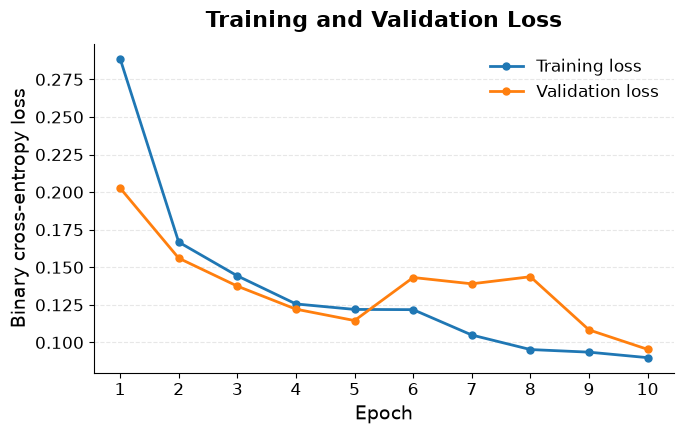

In [56]:
#| label: training-curves-output

epochs = np.arange(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    epochs,
    history["training_loss"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Training loss",
)

ax.plot(
    epochs,
    history["validation_loss"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Validation loss",
)

ax.set_title(
    "Training and Validation Loss",
    fontweight="bold",
    pad=12,
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Binary cross-entropy loss")

ax.set_xticks(epochs)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
)

fig.tight_layout()

:::{figure} #training-curves-output
:label: fig-training-curves
:align: center
:width: 70%

Training and validation loss across epochs. Comparing the two curves can help identify underfitting, a reasonable fit, or possible overfitting.

:::

:::{admonition} Reflection
:class: question

Do the curves suggest underfitting, a reasonable fit, or possible overfitting? What additional evidence would you need before deciding?

```{dropdown} Suggested response
Look at whether both losses remain high, decrease together, or diverge. The interpretation should also consider validation metrics, repeated runs, learning curves, and whether the validation split represents the intended population.
```
:::


## 8. Evaluating an Image Classifier in Healthcare

Accuracy alone is often insufficient for evaluating healthcare classifiers, especially when the classes are imbalanced or when different types of errors have different clinical consequences.

For a positive class such as pneumonia, **precision**, also called **positive predictive value (PPV)**, is calculated as:

```{math}
:label: precision

\mathrm{Precision}
=
\mathrm{PPV}
=
\frac{TP}{TP + FP}
```

**Sensitivity**, also called **recall** or the **true positive rate**, is calculated as:

```{math}
:label: sensitivity

\mathrm{Sensitivity}
=
\mathrm{Recall}
=
\frac{TP}{TP + FN}
```

**Specificity**, also called the **true negative rate**, is calculated as:

```{math}
:label: specificity

\mathrm{Specificity}
=
\frac{TN}{TN + FP}
```

**Negative predictive value (NPV)** is calculated as:

```{math}
:label: npv

\mathrm{NPV}
=
\frac{TN}{TN + FN}
```

where {math}`TP` represents true positives, {math}`FN` represents false negatives, {math}`TN` represents true negatives, and {math}`FP` represents false positives.

* **Sensitivity** is the proportion of positive cases that the model correctly identifies.
* **Specificity** is the proportion of negative cases that the model correctly identifies.
* **PPV** describes how often a positive prediction corresponds to a true positive.
* **NPV** describes how often a negative prediction corresponds to a true negative.

:::{admonition} Why accuracy may be misleading
:class: note

A model can achieve high accuracy by predicting the majority class most of the time. For example, if pneumonia cases are uncommon, a model may appear accurate while still missing many patients with pneumonia. Sensitivity, specificity, precision, and the confusion matrix provide more information about the types of errors the model makes.


#### Generate Predictions for the Test Set

In [57]:
def collect_predictions(model, data_loader, device):
    """Collect labels, logits, and probabilities in loader order."""
    model.eval()

    all_labels = []
    all_logits = []

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)
            logits = model(batch_images)

            all_logits.append(logits.cpu())
            all_labels.append(batch_labels.squeeze(1).cpu())

    labels = torch.cat(all_labels).numpy().astype(int)
    logits = torch.cat(all_logits).numpy()
    probabilities = 1.0 / (1.0 + np.exp(-logits))

    return labels, logits, probabilities


test_labels, test_logits, test_probabilities = collect_predictions(
    model, test_loader, device
)

print("Number of test predictions:", len(test_probabilities))
print(
    "Probability range:",
    f"{test_probabilities.min():.3f} to {test_probabilities.max():.3f}",
)


Number of test predictions: 624
Probability range: 0.000 to 1.000


#### Calculate Classification Performance Metrics

In [58]:
def binary_classification_metrics(labels, probabilities, threshold=0.5):
    """Calculate threshold-dependent and threshold-independent metrics."""

    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(labels, predictions),
        "AUROC": roc_auc_score(labels, probabilities),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision (PPV)": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "NPV": npv,
        "F1 score": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "True negatives": tn,
        "False positives": fp,
        "False negatives": fn,
        "True positives": tp,
    }


metrics_at_05 = binary_classification_metrics(
    test_labels,
    test_probabilities,
    threshold=0.5,
)

metrics_df = pd.DataFrame([metrics_at_05])

performance_cols = [
    "Threshold",
    "Accuracy",
    "AUROC",
    "Sensitivity",
    "Specificity",
    "Precision (PPV)",
    "NPV",
    "F1 score",
]

count_cols = [
    "True negatives",
    "False positives",
    "False negatives",
    "True positives",
]

display(
    metrics_df[performance_cols].style
    .format("{:.3f}")
    .hide(axis="index")
)

display(
    metrics_df[count_cols].style
    .format("{:.0f}")
    .hide(axis="index")
)

Threshold,Accuracy,AUROC,Sensitivity,Specificity,Precision (PPV),NPV,F1 score
0.500,0.896,0.951,0.946,0.812,0.893,0.900,0.919


True negatives,False positives,False negatives,True positives
190,44,21,369


:::{admonition} Interpretation
:class: note

These numbers describe performance on the predefined PneumoniaMNIST test split only. They do not establish performance in another hospital, device, age group, disease spectrum, or clinical workflow.
:::


#### Visualize the Confusion Matrix

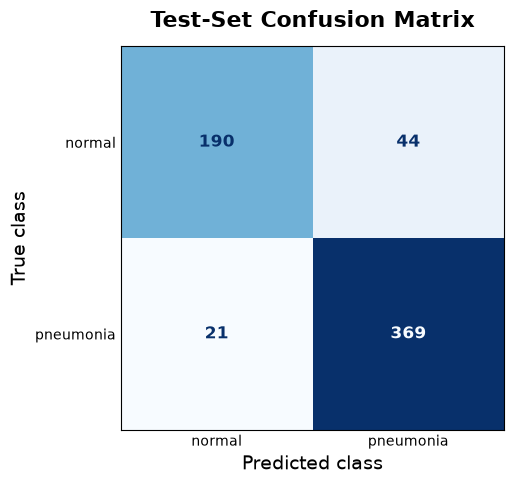

In [59]:
#| label: confusion-matrix-output

test_predictions = (test_probabilities >= 0.5).astype(int)

cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5.5, 5))

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[label_map[0], label_map[1]],
)

cm_display.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title(
    "Test-Set Confusion Matrix",
    fontweight="bold",
    pad=14,
)

ax.set_xlabel(
    "Predicted class",
)

ax.set_ylabel(
    "True class",
)

ax.tick_params(
    axis="both",
    labelsize=10,
)

# Make the counts easier to read
for text in ax.texts:
    text.set_fontweight("bold")

# Remove the small tick marks
ax.tick_params(
    axis="both",
    which="both",
    length=0,
)

fig.tight_layout()

:::{figure} #confusion-matrix-output
:label: fig-confusion-matrix
:align: center
:width: 60%

Test-set confusion matrix using a probability threshold of 0.5. The matrix summarizes true-positive, false-positive, true-negative, and false-negative predictions.

:::

#### Visualize the Receiver Operating Characteristic Curve

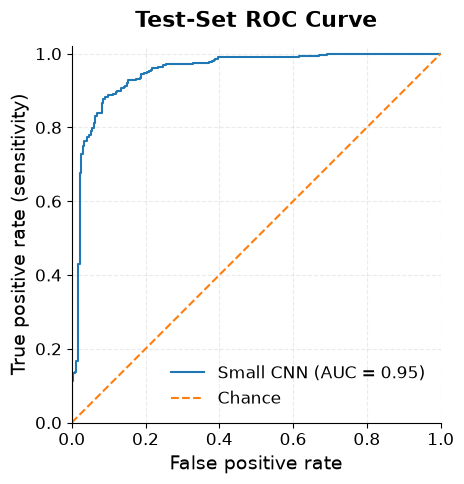

In [60]:
#| label: roc-curve-output

fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    test_labels,
    test_probabilities,
    name="Small CNN",
    ax=ax,
    # linewidth=2.5,
)

# Chance-level classifier
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Chance",
)

ax.set_title(
    "Test-Set ROC Curve",
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate (sensitivity)")

ax.grid(
    linestyle="--",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="lower right",
    frameon=False,
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

fig.tight_layout()

:::{figure} #roc-curve-output
:label: fig-roc-curve
:align: center
:width: 65%

Receiver operating characteristic curve for the model evaluated on the predefined test split. The curve shows the relationship between sensitivity and the false-positive rate across classification thresholds.

:::

### 8.1 Examine the decision threshold

The predicted probability must be converted into a class decision using a threshold. Changing the threshold changes the balance between sensitivity and specificity.


#### Examine Sensitivity and Specificity Across Thresholds

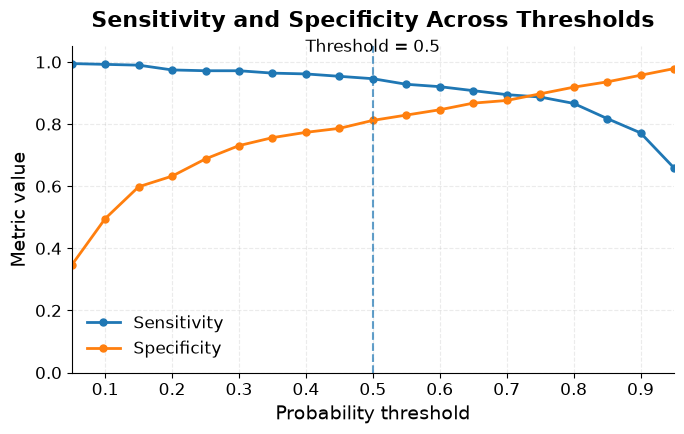

In [61]:
#| label: threshold-tradeoff-output

threshold_rows = []

for threshold in np.linspace(0.05, 0.95, 19):
    threshold_rows.append(
        binary_classification_metrics(
            test_labels,
            test_probabilities,
            threshold=float(threshold),
        )
    )

threshold_results = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Sensitivity"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Sensitivity",
)

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Specificity"],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Specificity",
)

# Highlight the commonly used threshold of 0.5
ax.axvline(
    0.5,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
)
ax.text(
    0.5,
    1.02,
    "Threshold = 0.5",
    ha="center",
    va="bottom",
)

ax.set_title(
    "Sensitivity and Specificity Across Thresholds",
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Probability threshold")
ax.set_ylabel("Metric value")

ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)

ax.grid(
    linestyle="--",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="best",
)

fig.tight_layout()

:::{figure} #threshold-tradeoff-output
:label: fig-threshold-tradeoff
:align: center
:width: 70%

Sensitivity and specificity across different probability thresholds. Lowering or raising the decision threshold changes the balance between false-negative and false-positive predictions.

:::

### Choosing a Decision Threshold

A binary classifier converts predicted probabilities into class labels using a **decision threshold**. A threshold of 0.5 is common, but it is not necessarily the most appropriate choice for every application. The threshold should reflect the intended use of the model and the relative consequences of false-positive and false-negative predictions.

For example:

* If the goal is to **minimize missed pneumonia cases**, a lower threshold may be selected to increase **sensitivity**. More images will be classified as positive, which can reduce false negatives but usually increases false positives.
* If the goal is to **avoid unnecessary follow-up for patients without pneumonia**, a higher threshold may be selected to increase **specificity**, although this may increase the number of missed positive cases.

:::{admonition} Threshold selection depends on the intended use
:class: note

There is no universally optimal probability threshold. A threshold should be selected using validation data based on the intended application and relevant performance requirements, and then evaluated on an independent test set.

PPV and NPV also depend on disease prevalence, so values observed in one dataset may change when the model is applied to a population with a different prevalence.

:::

:::{admonition} Check your understanding
:class: question

Why should the threshold not be selected by looking at the test set repeatedly?

```{dropdown} Answer
Repeatedly selecting a threshold based on test performance leaks information from the test set into model development. The threshold should be selected using validation data and justified using the intended clinical context. The untouched test set should be used for final evaluation.
```
:::


### 8.2 Review false positives and false negatives

Aggregate metrics can hide recurring error patterns. Reviewing individual errors can reveal artefacts, low-quality images, unusual anatomy, or systematic model failures.

The following examples are shown for educational inspection only. They do not establish why the model made each prediction.


#### Define Helper Functions for Reviewing Classification Errors

In [62]:
def denormalize_image(image_tensor, mean, std):
    """Convert a normalized 1-channel tensor back to the 0-1 display range."""
    image = image_tensor.squeeze(0).numpy() * std + mean
    return np.clip(image, 0, 1)


def show_error_examples(
    dataset,
    labels,
    probabilities,
    error_type,
    mean,
    std,
    max_examples=6,
):
    """Display false-positive or false-negative examples."""
    predictions = (probabilities >= 0.5).astype(int)

    if error_type == "false_positive":
        indices = np.where((labels == 0) & (predictions == 1))[0]
        heading = "False positives"
    elif error_type == "false_negative":
        indices = np.where((labels == 1) & (predictions == 0))[0]
        heading = "False negatives"
    else:
        raise ValueError(
            "error_type must be 'false_positive' or 'false_negative'."
        )

    indices = indices[:max_examples]

    if len(indices) == 0:
        print(f"No {heading.lower()} occurred at threshold 0.5.")
        return

    fig, axes = plt.subplots(
        1, len(indices), figsize=(2.4 * len(indices), 2.8)
    )

    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        image, _ = dataset[int(idx)]
        image_for_display = denormalize_image(image, mean, std)

        ax.imshow(image_for_display, cmap="gray", vmin=0, vmax=1)
        ax.set_title(
            f"True: {label_map[int(labels[idx])]}\n"
            f"P(pneumonia): {probabilities[idx]:.2f}",
        )
        ax.axis("off")

    fig.suptitle(heading)
    fig.tight_layout()
    return fig



#### Review False-Positive Predictions

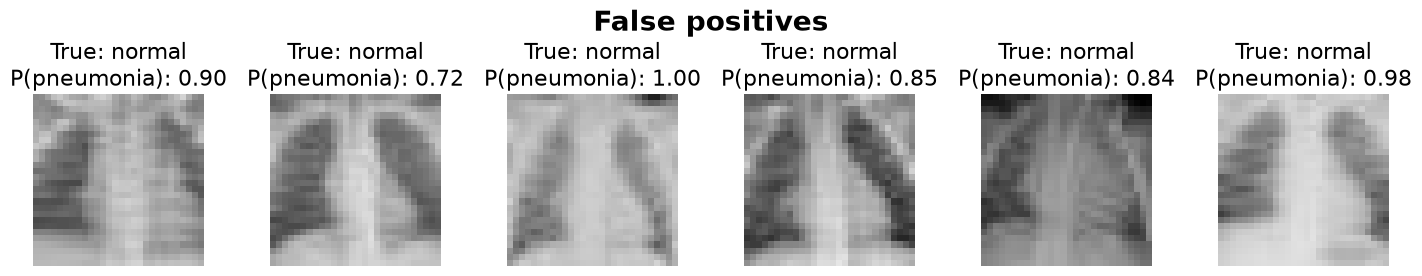

In [63]:
#| label: false-positive-predictions-output
fig = show_error_examples(
    test_dataset,
    test_labels,
    test_probabilities,
    error_type="false_positive",
    mean=train_mean,
    std=train_std,
)

:::{figure} #false-positive-predictions-output
:label: fig-false-positive-predictions
:align: center
:width: 95%

Examples of false-positive predictions, where the model predicted pneumonia for images labelled as normal. The displayed probabilities represent the model’s estimated probability of pneumonia.

:::

#### Review False-Negative Predictions

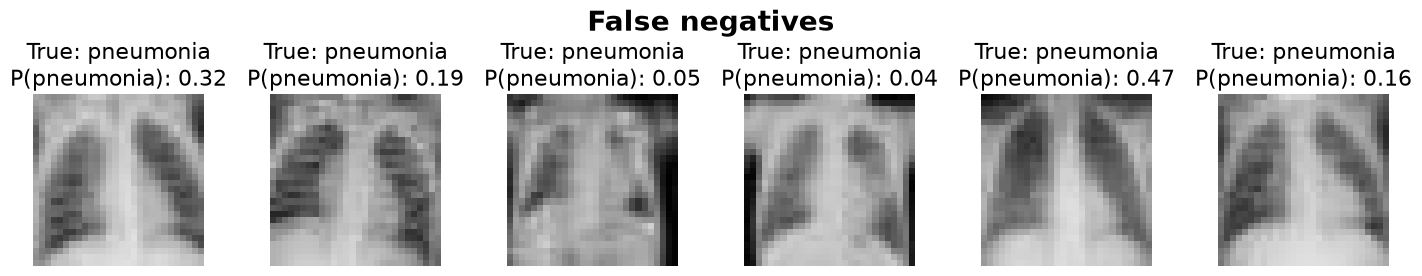

In [64]:
#| label: false-negative-predictions-output

fig = show_error_examples(
    test_dataset,
    test_labels,
    test_probabilities,
    error_type="false_negative",
    mean=train_mean,
    std=train_std,
)


:::{figure} #false-negative-predictions-output
:label: fig-false-negative-predictions
:align: center
:width: 95%

Examples of false-negative predictions, where the model predicted normal for images labelled as pneumonia. False negatives may be particularly important when missing a positive case could have harmful consequences.

:::

:::{admonition} Reflection
:class: question

Which error would be more consequential in the intended setting: a false positive or a false negative? There is no universal answer. Describe the intended use, who acts on the result, and what happens after each type of error.
:::


## 9. Interpretation and Grad-CAM

Grad-CAM uses gradients flowing into a convolutional layer to produce a coarse, class-specific localization map associated with a model output [@selvaraju2017gradcam]. It can be useful for exploratory interpretation and error analysis.

However, a Grad-CAM heatmap:

* Is not a validated segmentation mask
* May be unstable across models or settings
* Can highlight a region without proving clinically valid reasoning
* Does not rule out shortcut learning or confounding
* Should not be treated as an explanation of causal reasoning

The code below uses [Captum](https://captum.ai/) to generate a Grad-CAM map for one test image.


#### Generate and Visualize a Grad-CAM Heatmap

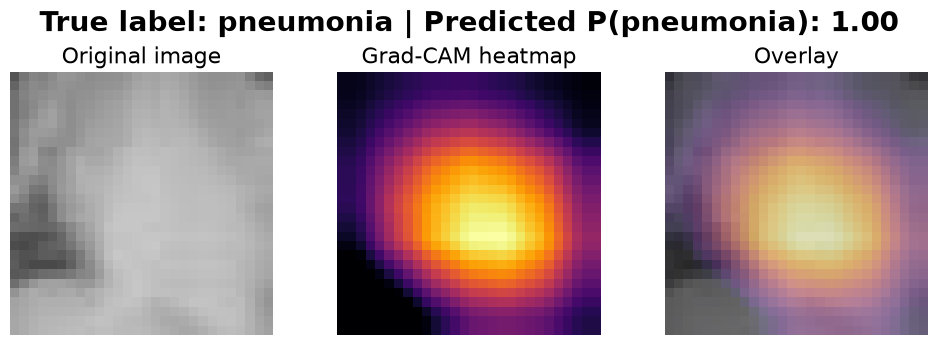

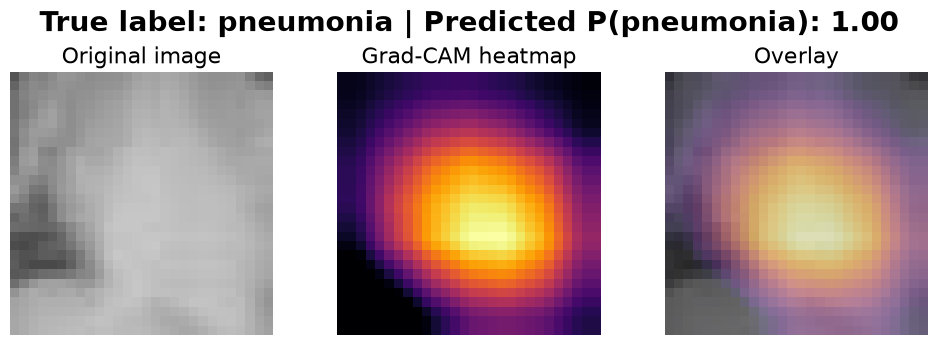

In [65]:
#| label: gradcam-output
from captum.attr import LayerAttribution, LayerGradCam


def make_gradcam(model, image, target_layer, device):
    """Generate an upsampled Grad-CAM map for the model's positive logit."""
    model.eval()

    input_batch = image.unsqueeze(0).to(device)
    gradcam = LayerGradCam(model, target_layer)

    attribution = gradcam.attribute(input_batch)
    attribution = LayerAttribution.interpolate(
        attribution,
        interpolate_dims=image.shape[-2:],
        interpolate_mode="bilinear",
    )

    heatmap = torch.relu(attribution).squeeze().detach().cpu().numpy()

    if heatmap.max() > heatmap.min():
        heatmap = (
            (heatmap - heatmap.min())
            / (heatmap.max() - heatmap.min())
        )
    else:
        heatmap = np.zeros_like(heatmap)

    with torch.no_grad():
        probability = torch.sigmoid(model(input_batch)).item()

    return heatmap, probability


# Select the test image with the highest predicted pneumonia probability.
gradcam_index = int(np.argmax(test_probabilities))
gradcam_image, gradcam_label = test_dataset[gradcam_index]

heatmap, gradcam_probability = make_gradcam(
    model,
    gradcam_image,
    target_layer=model.features[6],
    device=device,
)

display_image = denormalize_image(
    gradcam_image, train_mean, train_std
)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].imshow(display_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original image")

axes[1].imshow(heatmap, cmap="inferno")
axes[1].set_title("Grad-CAM heatmap")

axes[2].imshow(display_image, cmap="gray", vmin=0, vmax=1)
axes[2].imshow(heatmap, cmap="inferno", alpha=0.45)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

true_label = label_map[int(np.asarray(gradcam_label).squeeze())]
fig.suptitle(
    f"True label: {true_label} | "
    f"Predicted P(pneumonia): {gradcam_probability:.2f}"
)
fig.tight_layout()
fig


:::{figure} #gradcam-output
:label: fig-gradcam
:align: center
:width: 85%

A Grad-CAM visualization for one test image. The heatmap is exploratory and should not be interpreted as a validated localization or as proof that the model relied on clinically meaningful features.

:::

## 10. Failure Modes and Clinical Generalizability

Image-based models can perform well on an internal benchmark and still fail in clinical use.A model may learn shortcuts—patterns that are predictive within the development dataset but do not represent the intended clinical features [@geirhos2020shortcut].

In chest radiography, pneumonia-detection performance has been shown to vary across institutions, demonstrating that strong internal performance may not transfer to different hospitals, populations, or acquisition environments [@zech2018generalization].

| Risk | What it can look like | Mitigation or evaluation question |
|---|---|---|
| **Data leakage** | Images from the same patient appear in multiple splits | Were splits created at the patient level before model development? |
| **Class imbalance** | High accuracy but poor performance for one class | Are class-specific metrics and precision-recall behaviour reported? |
| **Shortcut learning** | The model relies on text markers, borders, devices, or acquisition patterns | Were artefacts and confounders examined? |
| **Domain shift** | Performance drops at another hospital or with another scanner | Was the model externally validated across sites and populations? |
| **Interpretability limitations** | A plausible heatmap is treated as proof of correct reasoning | Were interpretation methods stress-tested and used cautiously? |
| **Poor calibration** | Predicted probabilities do not match observed frequencies | Was calibration assessed on relevant held-out data? |
| **Limited clinical validity** | Benchmark performance is mistaken for patient benefit | Was the intended use evaluated prospectively in a clinical workflow? |

The PneumoniaMNIST example is especially limited because it uses low-resolution images from a pediatric source population. The notebook demonstrates a machine-learning workflow, not a clinically validated diagnostic pathway.


### Clinical-translation check

Before interpreting an image-model result, ask:

1. **Population:** Who contributed the data? Who is missing?
2. **Provenance:** How were images acquired, labelled, and preprocessed?
3. **Splitting:** Were patients, sites, and time periods separated appropriately?
4. **Outcome:** Does the label represent the clinical concept of interest?
5. **Errors:** What happens after a false positive or false negative?
6. **Generalizability:** Has performance been evaluated externally?
7. **Workflow:** Who will use the output, and how will it affect care?
8. **Monitoring:** How will performance and failure modes be monitored after deployment?

Transparent reporting is also necessary for evaluating whether a medical imaging study is reproducible and clinically meaningful. The Checklist for Artificial Intelligence in Medical Imaging, or CLAIM, provides reporting recommendations for artificial-intelligence studies involving medical images [@mongan2020claim].

:::{admonition} Activity
:class: question

Write a two- or three-sentence limitation statement for the model trained in this notebook. It should mention the source population, image resolution, and why the test result does not establish clinical validity.

```{dropdown} Example response
This educational model was trained and evaluated using standardized 28 × 28 pediatric chest X-rays from PneumoniaMNIST. Its performance on the predefined benchmark split may not generalize to other hospitals, scanners, age groups, disease spectra, or clinical workflows. External validation and prospective clinical evaluation would be required before considering any clinical use.
```
:::


## 11. Optional Extension: Transfer Learning with ResNet-18

The main example trains a small CNN from scratch. As an extension, you can adapt a pretrained ResNet-18.

A pretrained ResNet generally expects three-channel inputs and preprocessing compatible with its pretrained weights. For grayscale images, one simple educational approach is to repeat the grayscale channel three times. This does not create new image information.


#### Prepare the Optional ResNet-18 Transfer-Learning Model

In [66]:
# OPTIONAL EXTENSION — set RUN_TRANSFER_LEARNING = True to prepare the model.
RUN_TRANSFER_LEARNING = False

if RUN_TRANSFER_LEARNING:
    from torchvision.models import ResNet18_Weights, resnet18

    weights = ResNet18_Weights.DEFAULT

    transfer_transform = transforms.Compose(
        [
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=weights.transforms().mean,
                std=weights.transforms().std,
            ),
        ]
    )

    transfer_model = resnet18(weights=weights)
    transfer_model.fc = nn.Linear(
        transfer_model.fc.in_features, 1
    )

    # Freeze the feature extractor for a fixed-feature experiment.
    for parameter in transfer_model.parameters():
        parameter.requires_grad = False

    for parameter in transfer_model.fc.parameters():
        parameter.requires_grad = True

    transfer_model = transfer_model.to(device)
    print(transfer_model.fc)
else:
    print("Transfer-learning extension skipped because it increases compute.")


Transfer-learning extension skipped because it increases compute.


:::{admonition} Extension questions
:class: question

1. Would you freeze the feature extractor or fine-tune it?
2. How would you compare the small CNN and ResNet-18 fairly?
3. What limitations arise from transferring features learned from natural RGB images to low-resolution grayscale medical images?
:::


## Summary

:::{admonition} Key Takeaways
:class: tip

* Digital images are spatially organized arrays. Deep-learning frameworks commonly represent image batches using the shape {math}`N \times C \times H \times W`.
* Classification, object detection, and segmentation address different questions and produce different types of outputs.
* Convolutional neural networks learn local filters and progressively more complex feature representations.
* Preprocessing and data augmentation must preserve clinically meaningful information and must be applied separately to the appropriate data splits.
* Image classifiers should be evaluated using class-specific and threshold-dependent metrics rather than accuracy alone.
* Heatmaps can support exploratory analysis, but they do not prove that a model relied on clinically valid features or reasoning.
* Strong performance on an internal benchmark does not establish external generalizability, clinical validity, or patient benefit.


## Further Resources

### Dataset and software

* [MedMNIST official website](https://medmnist.com/)
* [MedMNIST GitHub repository](https://github.com/MedMNIST/MedMNIST)
* [PyTorch tutorials](https://docs.pytorch.org/tutorials/)
* [PyTorch transfer-learning tutorial](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
* [TorchVision models and pretrained weights](https://docs.pytorch.org/vision/stable/models.html)
* [scikit-learn model-evaluation documentation](https://scikit-learn.org/stable/modules/model_evaluation.html)
* [Captum model-interpretability documentation](https://captum.ai/)
* [MONAI tutorials](https://github.com/Project-MONAI/tutorials)

### Open educational visualizations

* [CNN Explainer](https://poloclub.github.io/cnn-explainer/)
* [Convolution Arithmetic](https://github.com/vdumoulin/conv_arithmetic)
* [Dive into Deep Learning: Convolutional Neural Networks](https://d2l.ai/chapter_convolutional-neural-networks/index.html)
* [Distill: Feature Visualization](https://distill.pub/2017/feature-visualization/)
